## Problem Statement:
#### Calculate churnrate for the telecommunication company based on their demographics.

### Objective:
#### The objective of this project is to understand the cutomer churn rate for Telco. 
- Churn rate means the average number of customers leaving the company service.
- Our goal is to predict the churn rate based on the customer demographics, and to predict how likely they are to stop using the company services.

#### Step 1: Data import and preprocessing

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns

In [2]:
pd.set_option('display.max_columns',None)            # we want to see all columns available in the dataset

In [3]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


- Let's discover the data types for all columns

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


- We will see if there are any null values in our dataset or not

In [6]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

- Let's see if our target column has balanced data points or not.

In [7]:
df['Churn'].value_counts(normalize=True)

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

<Axes: xlabel='Churn', ylabel='count'>

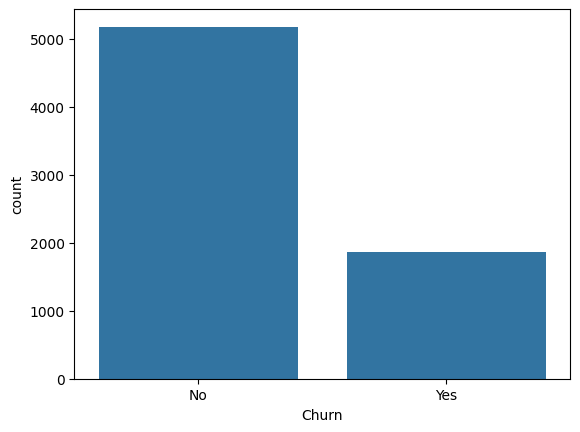

In [8]:
sns.countplot(x='Churn', data=df)

In [9]:
df['tenure'].describe()

count    7043.000000
mean       32.371149
std        24.559481
min         0.000000
25%         9.000000
50%        29.000000
75%        55.000000
max        72.000000
Name: tenure, dtype: float64

<Axes: xlabel='tenure', ylabel='Count'>

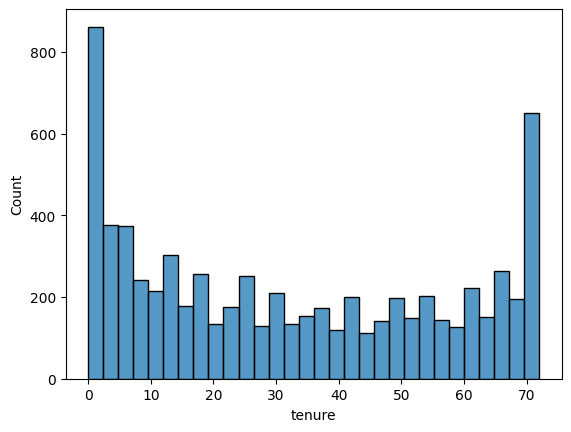

In [10]:
sns.histplot(df['tenure'], bins=30)

- Our target column Churn has  yes/no type of categorical data so we can transform them into the numerical categories as 1/0. Most models work best with numerical values so by transforming them we cab improve our model performance.

In [11]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No':0})

In [12]:
df['Contract'].value_counts(normalize=True)

Contract
Month-to-month    0.550192
Two year          0.240664
One year          0.209144
Name: proportion, dtype: float64

<Axes: xlabel='Contract', ylabel='Churn'>

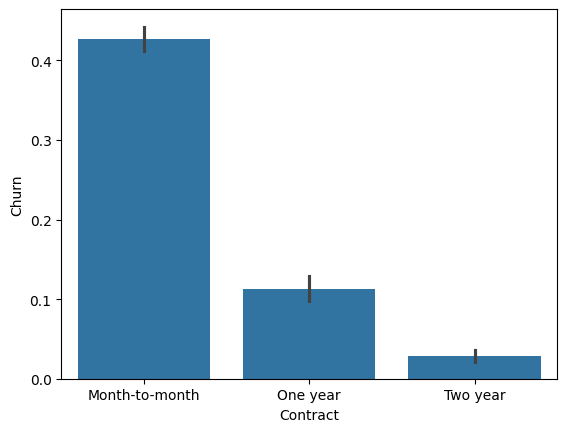

In [13]:
sns.barplot(x='Contract', y='Churn', data=df)

In [14]:
df.groupby('Contract')['Churn'].mean()

Contract
Month-to-month    0.427097
One year          0.112695
Two year          0.028319
Name: Churn, dtype: float64

In [15]:
df.groupby(pd.cut(df['tenure'], bins=5))['Churn'].mean()

C:\Users\Dell\AppData\Local\Temp\ipykernel_1908\3201036854.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(pd.cut(df['tenure'], bins=5))['Churn'].mean()


tenure
(-0.072, 14.4]    0.463518
(14.4, 28.8]      0.261989
(28.8, 43.2]      0.217391
(43.2, 57.6]      0.149947
(57.6, 72.0]      0.073292
Name: Churn, dtype: float64

In [16]:
df.groupby('PaperlessBilling')['Churn'].mean()

PaperlessBilling
No     0.163301
Yes    0.335651
Name: Churn, dtype: float64

In [17]:
df.groupby('PaymentMethod')['Churn'].mean()

PaymentMethod
Bank transfer (automatic)    0.167098
Credit card (automatic)      0.152431
Electronic check             0.452854
Mailed check                 0.191067
Name: Churn, dtype: float64

In [18]:
df.groupby(['PaymentMethod','Contract'])['Churn'].mean()

PaymentMethod              Contract      
Bank transfer (automatic)  Month-to-month    0.341256
                           One year          0.097187
                           Two year          0.033688
Credit card (automatic)    Month-to-month    0.327808
                           One year          0.103015
                           Two year          0.022375
Electronic check           Month-to-month    0.537297
                           One year          0.184438
                           Two year          0.077381
Mailed check               Month-to-month    0.315789
                           One year          0.068249
                           Two year          0.007853
Name: Churn, dtype: float64

In [19]:
df.groupby(['PaperlessBilling','Contract'])['Churn'].mean()

PaperlessBilling  Contract      
No                Month-to-month    0.314973
                  One year          0.071322
                  Two year          0.016484
Yes               Month-to-month    0.482985
                  One year          0.147500
                  Two year          0.042038
Name: Churn, dtype: float64

- With this we can say that Customers with longer contracts have lower churn-rate with compare to customer with month on month contract.
- Customers with automatic payment method also have a better churn rate with compare to customers with manual payment method.
- Customers with month-to-month paperless billing have higher churn rate.
- As the customer tenure increases the Churn rate decreases so cutomer tenure has reciprocal relation with Churn rate.

- So as seen we have relatively more No values than Yes, so our data is imbalanced data.

- Now we have to see unique values inside the categorical data columns so that we can transform each column accordingly. 

In [20]:
for col in df.columns:
    print(col,df[col].unique())

customerID ['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK']
gender ['Female' 'Male']
SeniorCitizen [0 1]
Partner ['Yes' 'No']
Dependents ['No' 'Yes']
tenure [ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26  0
 39]
PhoneService ['No' 'Yes']
MultipleLines ['No phone service' 'No' 'Yes']
InternetService ['DSL' 'Fiber optic' 'No']
OnlineSecurity ['No' 'Yes' 'No internet service']
OnlineBackup ['Yes' 'No' 'No internet service']
DeviceProtection ['No' 'Yes' 'No internet service']
TechSupport ['No' 'Yes' 'No internet service']
StreamingTV ['No' 'Yes' 'No internet service']
StreamingMovies ['No' 'Yes' 'No internet service']
Contract ['Month-to-month' 'One year' 'Two year']
PaperlessBilling ['Yes' 'No']
PaymentMethod ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (a

- Now we can see there is a Total charge column with numerical values but its data type is object, which means there are some non-integer values in this column. We have to identify and transfrom them.

In [21]:
df['TotalCharges'] = df['TotalCharges'].str.strip()

In [22]:
import numpy as np

df['TotalCharges'] = df['TotalCharges'].replace('', np.nan)

In [23]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'])

In [24]:
df.dropna(inplace=True)

- There are blank spaces in some data points so we will replace them with 0, and also we will change the datatype of other data points as well.

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null   object 
 17  

In [26]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


#### 
- The customer id column doesn't add any significant value to the model performace so we can safely remove that column from the dataset.

In [27]:
df = df.drop('customerID',axis=1)
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


- Now lets change the categorical columns using get dummies method. Basically we will do encoding where categorical values will become columns for better model performance.

- Now we will move ahead with the model training, we have to predict the customer churn which is a categorical value 0/1. Basically the customer will leave the netwrok (0) or not (1)
- First we will split our data into two parts, 80% training and 20% testing.

In [28]:
from sklearn.model_selection import train_test_split
X = df.drop("Churn",axis=1)
y = df['Churn']

X = pd.get_dummies(X,drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,stratify=y)

In [29]:
X.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,False,True,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,True,False,False,True,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,True,False,False,True,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,True,False,False,False,True,False,False,False,False,True,False,False,False,True,False,True,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False


- Let's train a simple Logistic classification model first, then we will move ahead with complex models.

#### Logistic Regression

In [30]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [31]:
from sklearn.linear_model import LogisticRegression
model_lr = LogisticRegression(max_iter=1000)
model_lr.fit(X_train,y_train)

LogisticRegression(max_iter=1000)

In [32]:
y_pred_lr = model_lr.predict(X_test)

In [33]:
from sklearn.metrics import accuracy_score, confusion_matrix

In [34]:
print('LR Accuracy: ',accuracy_score(y_test,y_pred_lr))
print('LR Confusion metrix: ', confusion_matrix(y_test,y_pred_lr))

LR Accuracy:  0.8038379530916845
LR Confusion metrix:  [[916 117]
 [159 215]]


In [35]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407



- Let's train a little more complex tree model, basically we will deep dive into complex relation between different parameters in our database.

#### Decision Tree

In [36]:
from sklearn.tree import DecisionTreeClassifier
model_tree = DecisionTreeClassifier(max_depth=5)
model_tree.fit(X_train,y_train)

DecisionTreeClassifier(max_depth=5)

In [37]:
y_pred_tree = model_tree.predict(X_test)

In [38]:
print("Accuracy Tree: ",accuracy_score(y_test,y_pred_tree))
print('Decision Tree Confusion metrix: ', confusion_matrix(y_test,y_pred_tree))
print(classification_report(y_test, y_pred_tree))

Accuracy Tree:  0.7782515991471215
Decision Tree Confusion metrix:  [[872 161]
 [151 223]]
              precision    recall  f1-score   support

           0       0.85      0.84      0.85      1033
           1       0.58      0.60      0.59       374

    accuracy                           0.78      1407
   macro avg       0.72      0.72      0.72      1407
weighted avg       0.78      0.78      0.78      1407



- Now we will move ahead with more complex model Random forest, basically we will combine multiple trees and see if our model performs better.

#### Random Forest

In [39]:
from sklearn.ensemble import RandomForestClassifier
model_rf = RandomForestClassifier(n_estimators=50,random_state=42)
model_rf.fit(X_train,y_train)

RandomForestClassifier(n_estimators=50, random_state=42)

In [40]:
y_pred_rf = model_rf.predict(X_test)

In [41]:
print("Accuracy RF: ", accuracy_score(y_test,y_pred_rf))
print("RF confusion matrix: ", confusion_matrix(y_test,y_pred_rf))
print(classification_report(y_test,y_pred_rf))

Accuracy RF:  0.7839374555792467
RF confusion matrix:  [[909 124]
 [180 194]]
              precision    recall  f1-score   support

           0       0.83      0.88      0.86      1033
           1       0.61      0.52      0.56       374

    accuracy                           0.78      1407
   macro avg       0.72      0.70      0.71      1407
weighted avg       0.77      0.78      0.78      1407



<Axes: >

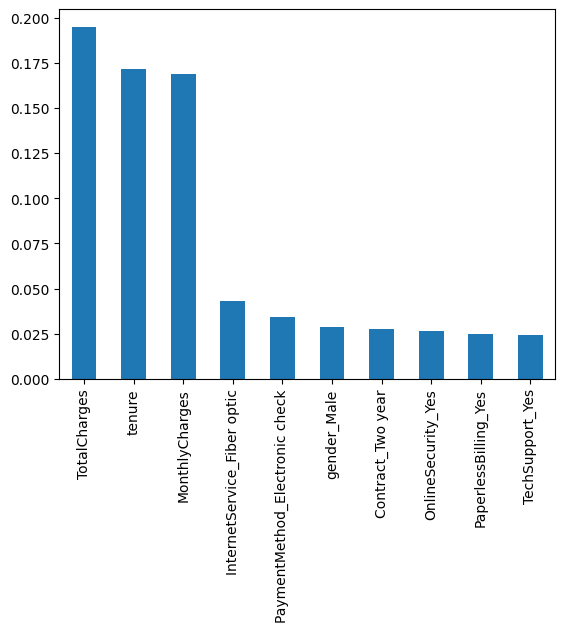

In [43]:
importances = model_rf.feature_importances_
feat_imp = pd.Series(importances, index=X.columns).sort_values(ascending=False)

feat_imp.head(10).plot(kind='bar')

- Based on all these models we can see that the Logistic Regression model which is the simplest model, provides us with the accuracy of 79% and f1 score of 78% while the random forest model provides us with accuracy of 79% and f1 score of 78%. Now based on the client requirement we can suggest linear refression or Random forest model as the accuracy is similar. If client wants to understand simple relations between data points then we will suggest linear regression model and if they want to have deeper relations within the data set then we will suggest random forest model.